## **Unsupervised Models – Isolation Forest & ECOD**

Unsupervised anomaly detection does not use labels during training — the model learns what "normal" looks like and flags deviations. This is useful as a baseline and for understanding whether anomalies are statistical outliers or behavioural patterns that require supervised learning.

**Models:**
- **Isolation Forest** — isolates anomalies via random partitioning; anomalies require fewer splits
- **ECOD** (Empirical Cumulative Distribution) — flags observations in the tails of each feature's distribution

**Key difference from supervised models:** scores are raw anomaly scores (not probabilities), so threshold choice matters more. Codabench uses a default threshold of 0.5 on normalised scores.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from pyod.models.ecod import ECOD

from feature_pipeline import (
    load_data, exclude_test_users, compute_item_stats,
    build_features, get_feature_columns, get_test_labels,
)
from analysis import (
    model_metrics, plot_score_distribution, plot_roc_curve,
    plot_pr_curve, plot_confusion_matrix,
)


def create_feature_df_trial(train_data, test_data):
    """Trial phase: test users are a subset of training, so we exclude them."""
    print("LOADING DATA (TRIAL PHASE)...")
    XX_train, yy_all, XX_test = load_data(train_data, test_data)
    XX_train, yy = exclude_test_users(XX_train, yy_all, XX_test)

    item_stats = compute_item_stats(XX_train)

    user_df = build_features(XX_train, item_stats).merge(yy, on="user")
    feature_cols = get_feature_columns(user_df)
    X_features = user_df[feature_cols].values
    y_labels = user_df["label"].values

    test_df = build_features(XX_test, item_stats)
    X_test = test_df[feature_cols].values
    test_labels = test_df[["user"]].merge(yy_all, on="user")["label"].values

    print(f"Train: {X_features.shape[0]} users, {len(feature_cols)} features")
    print(f"Test:  {X_test.shape[0]} users ({int(test_labels.sum())} anomalous)")
    return X_features, y_labels, X_test, feature_cols, test_labels


def create_feature_df(train_data, test_data, labeled_test_data=None):
    """Competition phase: test users are unseen."""
    print("LOADING DATA...")
    XX_train, yy_all, XX_test = load_data(train_data, test_data)

    item_stats = compute_item_stats(XX_train)

    user_df = build_features(XX_train, item_stats).merge(yy_all, on="user")
    feature_cols = get_feature_columns(user_df)
    X_features = user_df[feature_cols].values
    y_labels = user_df["label"].values

    test_df = build_features(XX_test, item_stats)
    X_test = test_df[feature_cols].values

    print(f"Train: {X_features.shape[0]} users, {len(feature_cols)} features")
    print(f"Test:  {X_test.shape[0]} users")

    if labeled_test_data is not None:
        test_labels = get_test_labels(labeled_test_data, test_df)
        print(f"Test labels loaded: {int(test_labels.sum())} anomalous")
        return X_features, y_labels, X_test, feature_cols, test_labels

    return X_features, y_labels, X_test, feature_cols

**Train unsupervised models – Isolation Forest, ECOD, & an ensemble**

In [3]:
def train_isolation_forest(X_features, n_estimators=1000, max_features=0.6):
    """Train Isolation Forest on scaled features. Returns (model, scaler)."""
    print(f"\nTRAINING ISOLATION FOREST (n_estimators={n_estimators}, max_features={max_features})...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_features)

    iso = IsolationForest(
        n_estimators=n_estimators,
        contamination="auto",
        max_features=max_features,
        random_state=42,
    )
    iso.fit(X_scaled)
    return iso, scaler


def train_ecod(X_features, scaler):
    """Train ECOD on the same scaled features. Returns the ECOD model."""
    print("TRAINING ECOD...")
    X_scaled = scaler.transform(X_features)
    ecod = ECOD()
    ecod.fit(X_scaled)
    return ecod


def get_scores(iso, ecod, scaler, X, blend_weight=0.6):
    """Score users with IF, ECOD, and a blended ensemble.

    Args:
        blend_weight: weight for Isolation Forest (1 - blend_weight goes to ECOD).

    Returns dict with keys 'isolation_forest', 'ecod', 'ensemble'.
    """
    X_scaled = scaler.transform(X)

    iso_raw = -iso.decision_function(X_scaled)
    ecod_raw = ecod.decision_function(X_scaled)

    iso_norm = MinMaxScaler().fit_transform(iso_raw.reshape(-1, 1)).ravel()
    ecod_norm = MinMaxScaler().fit_transform(ecod_raw.reshape(-1, 1)).ravel()
    ensemble = blend_weight * iso_norm + (1 - blend_weight) * ecod_norm

    return {
        "Isolation Forest": iso_norm,
        "ECOD": ecod_norm,
        "Ensemble (IF+ECOD)": ensemble,
    }

**Evaluation & threshold analysis**

In [4]:
def evaluate_all(scores_dict, test_labels, batch_name):
    """Run standard evaluation (AUC, PR, confusion matrix) for each model variant."""
    for name, scores in scores_dict.items():
        print(f"\n{'='*60}")
        model_metrics(test_labels, scores, name)
        plot_score_distribution(test_labels, scores, name, batch_name)
        plot_roc_curve(test_labels, scores, name, batch_name)
        plot_pr_curve(test_labels, scores, name, batch_name)
        plot_confusion_matrix(test_labels, scores, name, batch_name)


def threshold_analysis(scores, test_labels, model_name):
    """Show how Precision, Recall, F1 change across thresholds.

    Highlights the Codabench default (0.5) and the best-F1 threshold so we can
    see whether tuning the threshold would improve the submission score.
    """
    thresholds = np.linspace(0.01, 0.99, 300)
    precisions, recalls, f1s = [], [], []

    for t in thresholds:
        preds = (scores >= t).astype(int)
        precisions.append(precision_score(test_labels, preds, zero_division=0))
        recalls.append(recall_score(test_labels, preds, zero_division=0))
        f1s.append(f1_score(test_labels, preds, zero_division=0))

    best_idx = np.argmax(f1s)
    best_t = thresholds[best_idx]

    # Metrics at Codabench default (0.5)
    preds_05 = (scores >= 0.5).astype(int)
    f1_05 = f1_score(test_labels, preds_05, zero_division=0)
    p_05 = precision_score(test_labels, preds_05, zero_division=0)
    r_05 = recall_score(test_labels, preds_05, zero_division=0)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(thresholds, precisions, label="Precision")
    ax.plot(thresholds, recalls, label="Recall")
    ax.plot(thresholds, f1s, label="F1", linewidth=2)

    ax.axvline(x=0.5, color="red", linestyle="--", alpha=0.7,
               label=f"Codabench 0.5 (F1={f1_05:.3f})")
    ax.axvline(x=best_t, color="green", linestyle="--", alpha=0.7,
               label=f"Best F1={f1s[best_idx]:.3f} @ t={best_t:.3f}")

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title(f"Threshold Analysis — {model_name}")
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"At Codabench default (t=0.5):  P={p_05:.4f}  R={r_05:.4f}  F1={f1_05:.4f}")
    print(f"At optimal threshold (t={best_t:.3f}): P={precisions[best_idx]:.4f}  R={recalls[best_idx]:.4f}  F1={f1s[best_idx]:.4f}")


def save_submission(scores, filename):
    """Save anomaly scores as a Codabench submission file."""
    np.savez(filename, predictions=scores)
    print(f"Saved to {filename}")

## **Trial Phase**

LOADING DATA (TRIAL PHASE)...
Excluded 220 overlapping users from training (1100 → 880 users)
Train: 880 users, 24 features
Test:  220 users (18 anomalous)

TRAINING ISOLATION FOREST (n_estimators=1000, max_features=0.6)...
TRAINING ECOD...

Isolation Forest
# AUC:       0.6161
# Precision: 0.2326
# Recall:    0.5556
# F1 Score:  0.3279


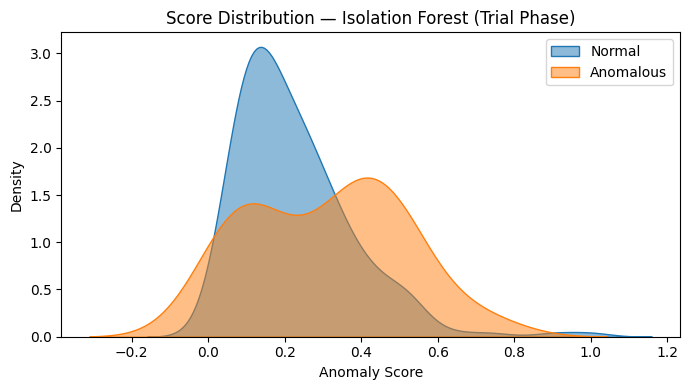

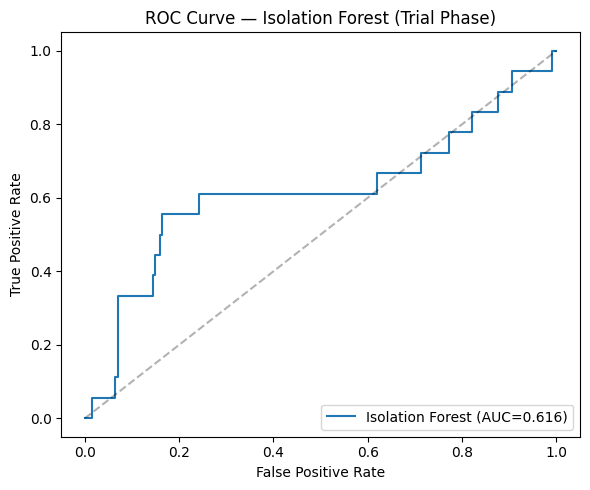

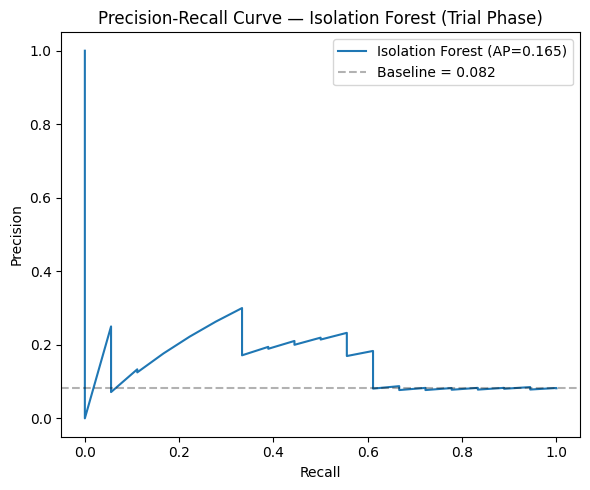

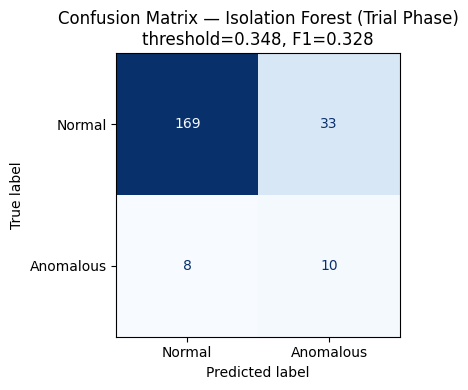


ECOD
# AUC:       0.6152
# Precision: 0.2308
# Recall:    0.3333
# F1 Score:  0.2727


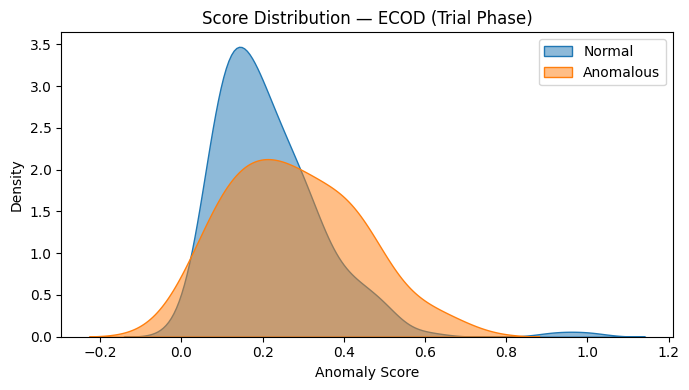

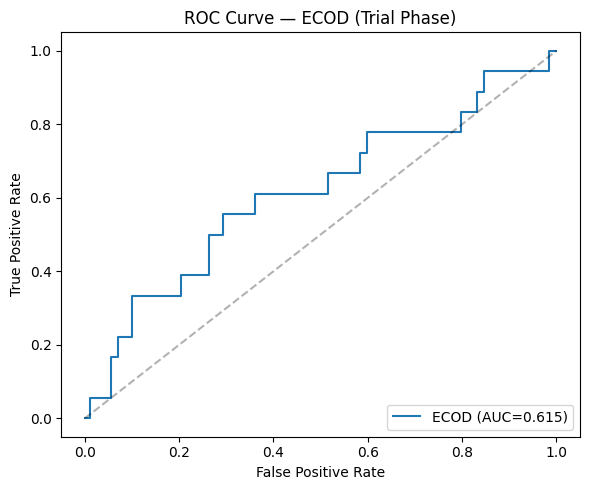

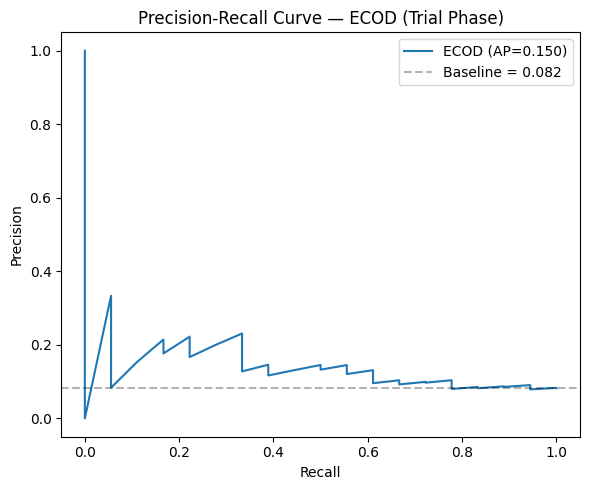

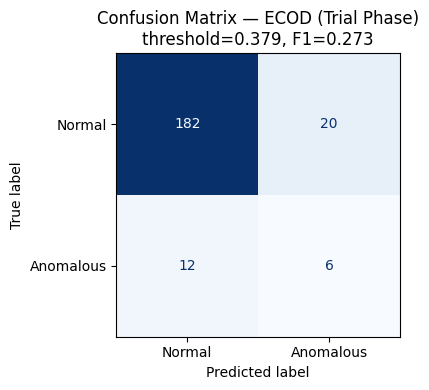


Ensemble (IF+ECOD)
# AUC:       0.6194
# Precision: 0.2727
# Recall:    0.3333
# F1 Score:  0.3000


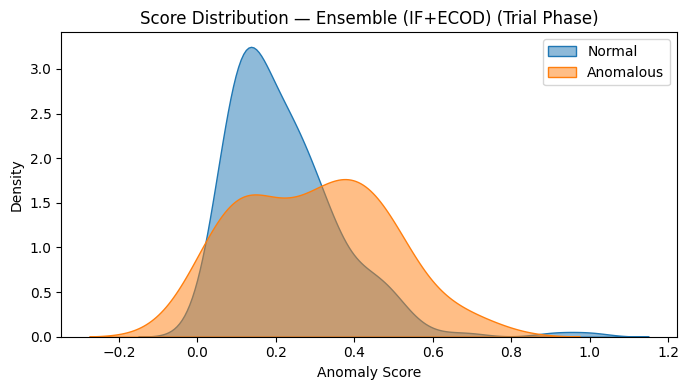

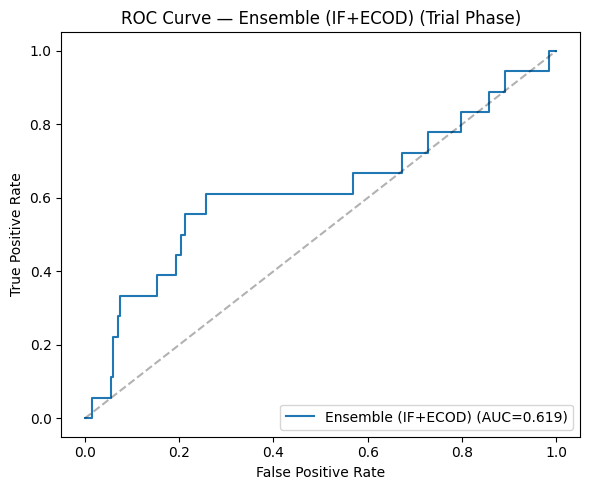

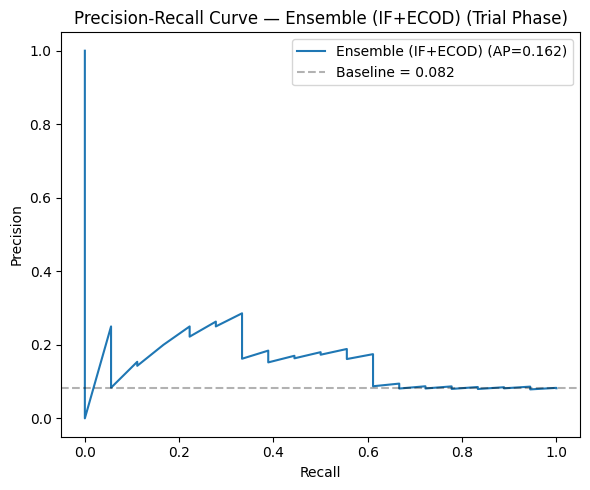

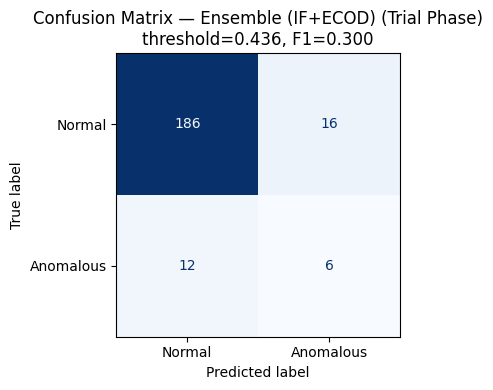

In [5]:
# Load data
X_features, y_labels, X_test, feature_cols, test_labels = create_feature_df_trial(
    "data/training_batch_with_labels.npz", "data/subset_training_batch.npz"
)

# Train models
iso, scaler = train_isolation_forest(X_features)
ecod = train_ecod(X_features, scaler)

# Score test set
test_scores = get_scores(iso, ecod, scaler, X_test)

# Evaluate all three variants
evaluate_all(test_scores, test_labels, "Trial Phase")

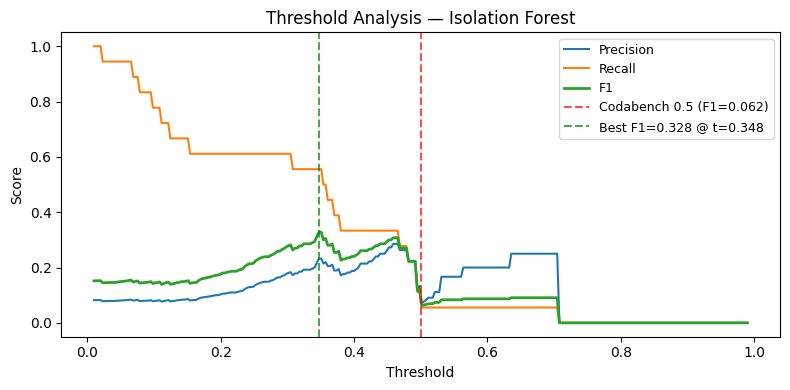

At Codabench default (t=0.5):  P=0.0714  R=0.0556  F1=0.0625
At optimal threshold (t=0.348): P=0.2326  R=0.5556  F1=0.3279


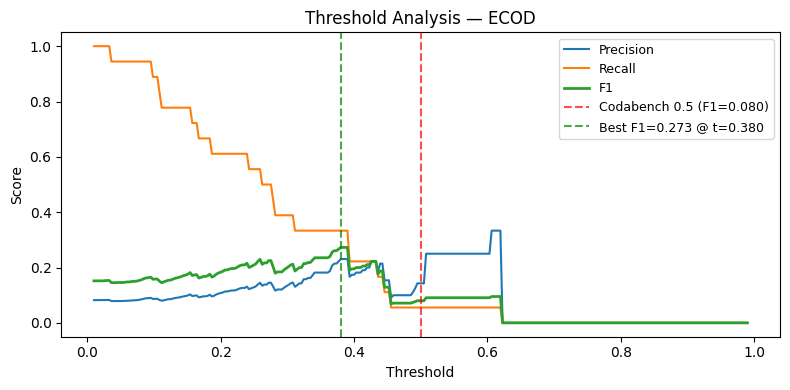

At Codabench default (t=0.5):  P=0.1429  R=0.0556  F1=0.0800
At optimal threshold (t=0.380): P=0.2308  R=0.3333  F1=0.2727


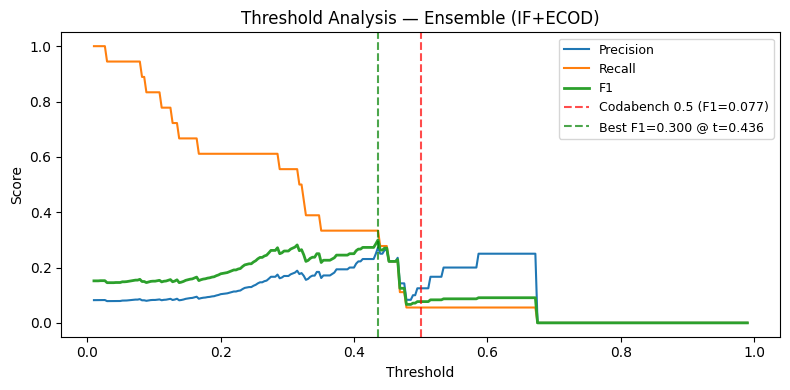

At Codabench default (t=0.5):  P=0.1250  R=0.0556  F1=0.0769
At optimal threshold (t=0.436): P=0.2727  R=0.3333  F1=0.3000


In [6]:
# Threshold analysis — note: default 0.5 threshold for Codabench
for name, scores in test_scores.items():
    threshold_analysis(scores, test_labels, name)

## **Phase 1: First Batch**

LOADING DATA...
Train: 1100 users, 24 features
Test:  1100 users
Test labels loaded: 100 anomalous

TRAINING ISOLATION FOREST (n_estimators=1000, max_features=0.6)...
TRAINING ECOD...

Isolation Forest
# AUC:       0.6280
# Precision: 0.3333
# Recall:    0.4100
# F1 Score:  0.3677


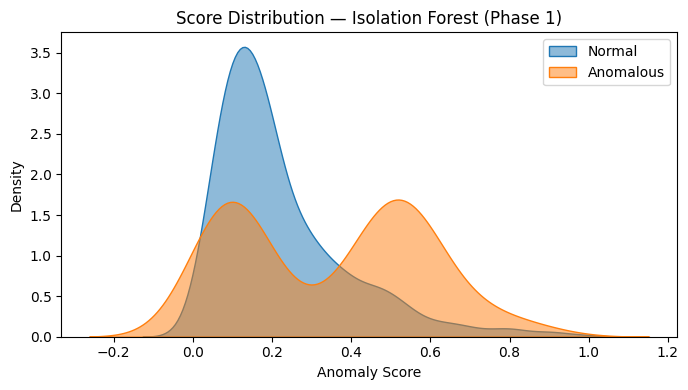

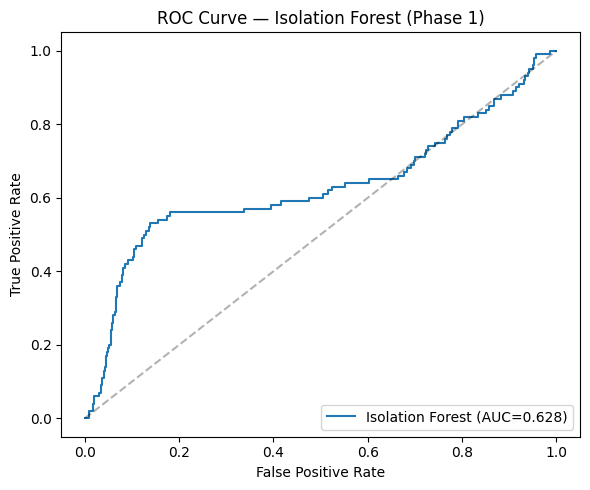

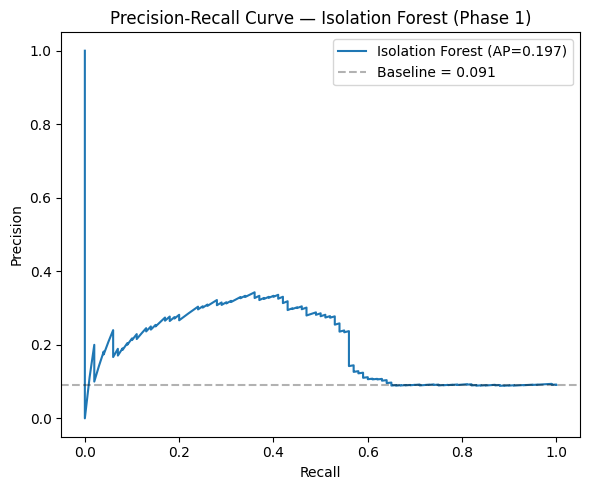

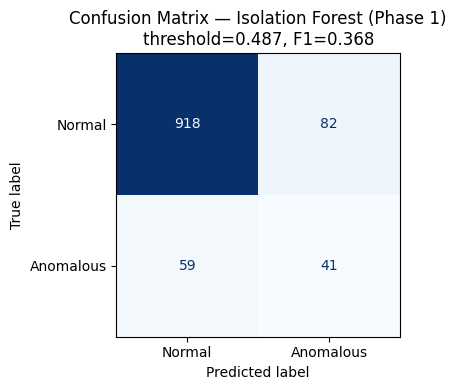


ECOD
# AUC:       0.6174
# Precision: 0.2539
# Recall:    0.4900
# F1 Score:  0.3345


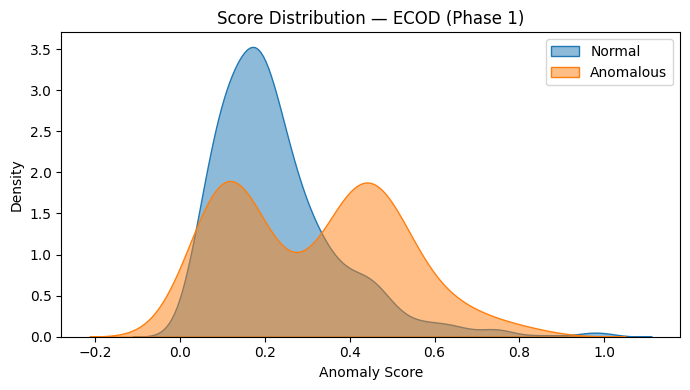

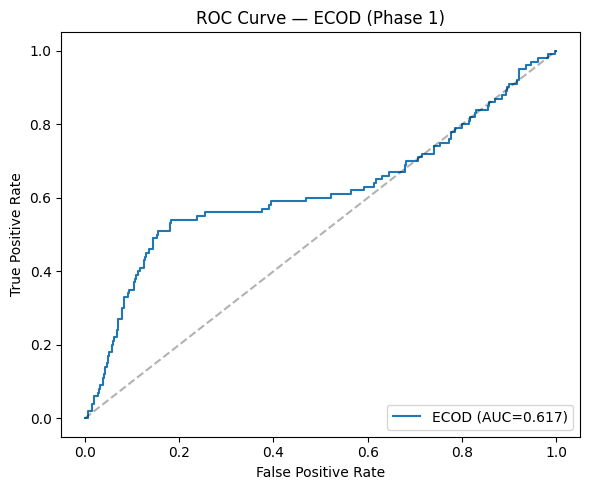

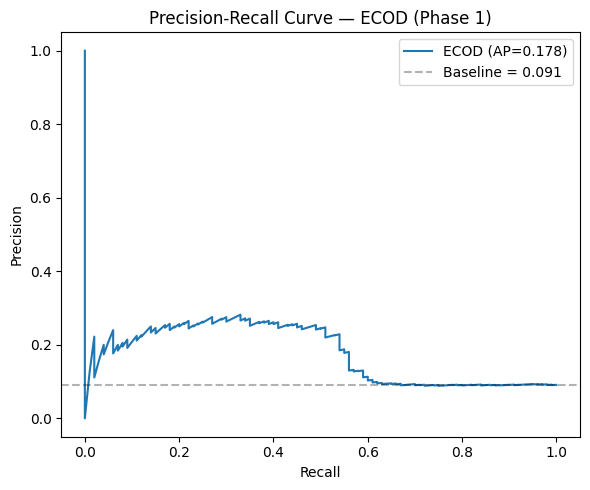

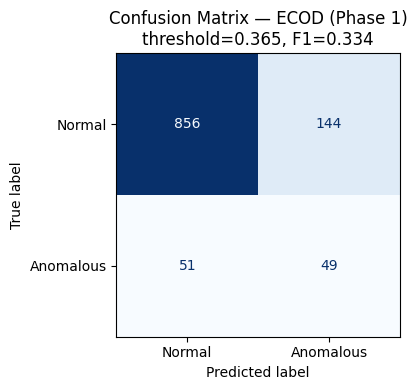


Ensemble (IF+ECOD)
# AUC:       0.6245
# Precision: 0.3419
# Recall:    0.4000
# F1 Score:  0.3687


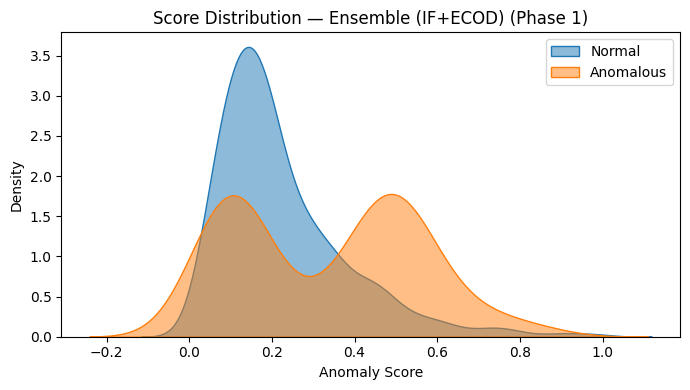

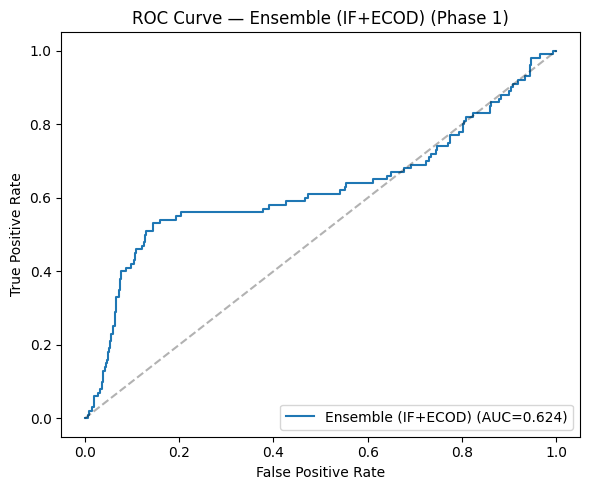

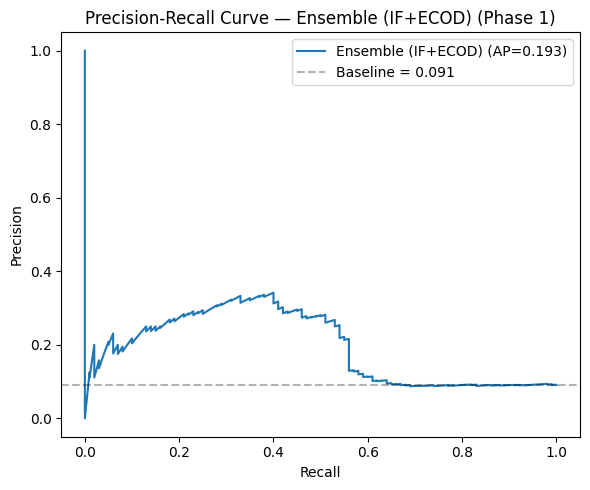

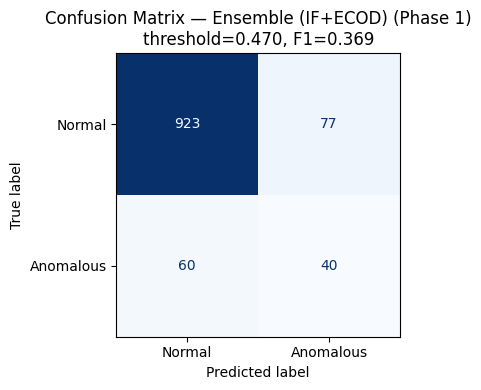

In [7]:
# Load data
X_features_p1, y_labels_p1, X_test_p1, feature_cols_p1, test_labels_p1 = create_feature_df(
    "data/training_batch_with_labels.npz", "data/first_batch.npz", "data/first_batch_with_labels.npz"
)

# Train models
iso_p1, scaler_p1 = train_isolation_forest(X_features_p1)
ecod_p1 = train_ecod(X_features_p1, scaler_p1)

# Score test set
test_scores_p1 = get_scores(iso_p1, ecod_p1, scaler_p1, X_test_p1)

# Evaluate
evaluate_all(test_scores_p1, test_labels_p1, "Phase 1")

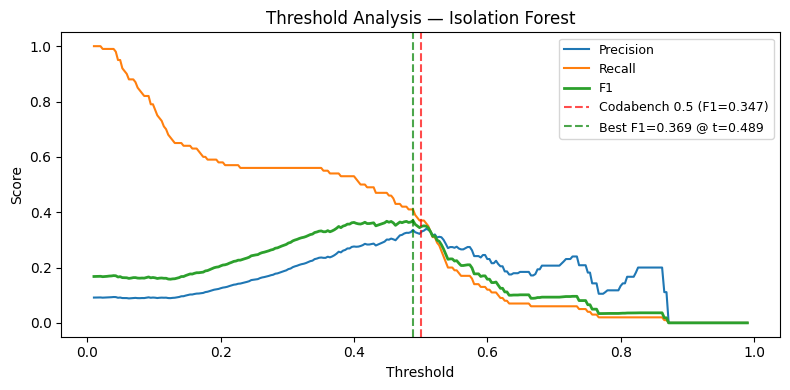

At Codabench default (t=0.5):  P=0.3274  R=0.3700  F1=0.3474
At optimal threshold (t=0.489): P=0.3361  R=0.4100  F1=0.3694


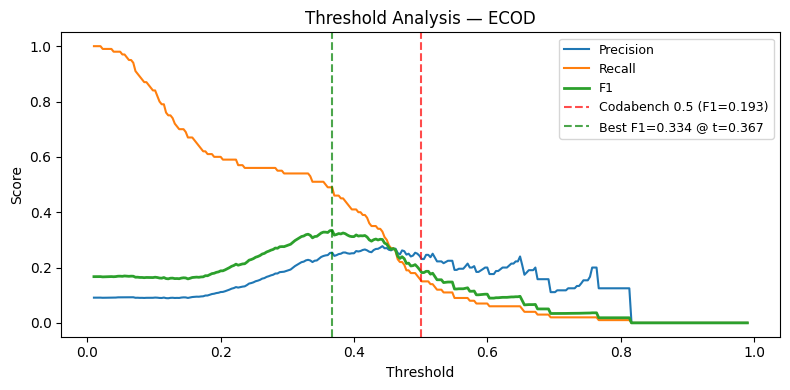

At Codabench default (t=0.5):  P=0.2424  R=0.1600  F1=0.1928
At optimal threshold (t=0.367): P=0.2539  R=0.4900  F1=0.3345


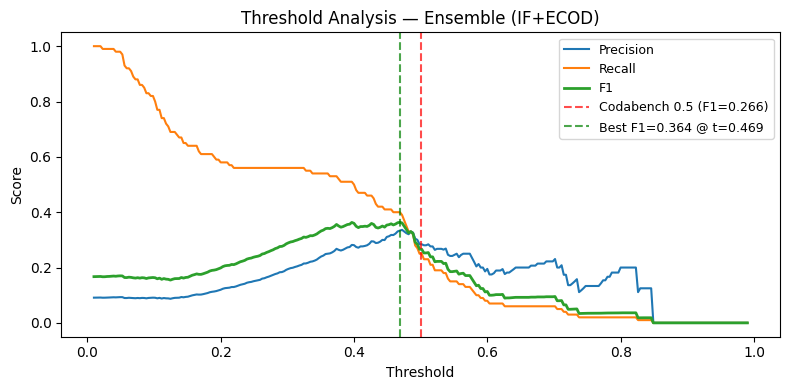

At Codabench default (t=0.5):  P=0.2841  R=0.2500  F1=0.2660
At optimal threshold (t=0.469): P=0.3333  R=0.4000  F1=0.3636
Saved to submission files/isolation_forest_p1.npz


In [8]:
# Threshold analysis
for name, scores in test_scores_p1.items():
    threshold_analysis(scores, test_labels_p1, name)

# Save best variant for submission
save_submission(test_scores_p1["Isolation Forest"], "submission files/isolation_forest_p1.npz")

## **Phase 2: Second Batch**

In [9]:
# Load data (no labels yet — use combine_labeled_data to pool training + phase 1 labels)
from feature_pipeline import combine_labeled_data

combined = combine_labeled_data(
    "data/training_batch_with_labels.npz",
    "data/first_batch_with_labels.npz",
)

X_features_p2, y_labels_p2, X_test_p2, feature_cols_p2 = create_feature_df(
    combined, "data/second_batch.npz"
)

# Train models on expanded training data
iso_p2, scaler_p2 = train_isolation_forest(X_features_p2)
ecod_p2 = train_ecod(X_features_p2, scaler_p2)

# Score test set
test_scores_p2 = get_scores(iso_p2, ecod_p2, scaler_p2, X_test_p2)

# Save submission (pick best variant based on earlier phase results)
save_submission(test_scores_p2["Isolation Forest"], "submission files/isolation_forest_p2.npz")

Combined 2 files → data/combined_training.npz
  2200 users (200 anomalous, 2000 normal), 344839 interactions
LOADING DATA...
Train: 2200 users, 24 features
Test:  860 users

TRAINING ISOLATION FOREST (n_estimators=1000, max_features=0.6)...
TRAINING ECOD...
Saved to submission files/isolation_forest_p2.npz
